## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est_t import *
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.static.master_class_parallel as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem
from skrom.utils.visualization.generate_vtk import *
from skrom.utils.visualization.generate_vtu import *
from skrom.utils.visualization.plot_utils import *
from skrom.utils.data_io.save_h5 import *


PETSc available: True


In [3]:
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce

In [4]:
import sci_mplstyle_package

### Plot Properties


In [5]:
from problem_def import Problem3Dprinting
set_color_palette();

## Full Order Simulation


In [6]:
import logging

# Global off switch
logging.disable(logging.CRITICAL)

# Also remove existing handlers that may already be attached in Jupyter
root = logging.getLogger()
for h in root.handlers[:]:
    root.removeHandler(h)
root.addHandler(logging.NullHandler())
root.setLevel(logging.CRITICAL)


In [7]:
_nnls = True
_hyperreduce = True
_randomized_svd = True
_ecsw_snapshots = True
visualize = False
run_hyperrom = True
run_svd = True
generate_data = False
rom_report = True

In [8]:
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots=2**3)
    sim.run_simulation(parallel=True,max_workers=1)
    

### Load Simulation Data

In [9]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\dynamic\problem_3D_printing_nu_mesh_HO\ROM_data


### Selective Visualization

In [10]:
if visualize:
    current_dir = Path().resolve()
    run_dir = current_dir / "results_1_21"

    save_vtu_time_series_point_vertexsample(
        fos_solutions[-1][50:, :],      # (n_steps, ndofs)
        sim_data['mesh'].item(),
        sim_data['basis'].item(),
        run_dir,
        "sol",
        interval=8,
        point_data_name="Temperature",
    )


### Generate Training Solution Dataset



In [11]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']


In [12]:
train_mask[15]=True
train_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False])

In [13]:
test_mask = ~train_mask

In [12]:
# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
# NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
# NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

In [15]:
# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, *_ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

24


### IC Subtraction

In [16]:
# Shape: [N_dof] - one ref value for each spatial degree of freedom
# NLS_train_mean =NLS[train_mask][:,0:1,:] 

# center the training data by subtracting the reference field
# This creates fluctuations/deviations from the reference temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now centered
# Each row now represents how much each snapshot deviates from the reference
NLS_train_ms = NLS[train_mask]- NLS[train_mask][:,0:1,:] 

#We will use SVD on the mean subtracted matrix data

### Performing SVD on training snapshots

Number of modes selected: 43


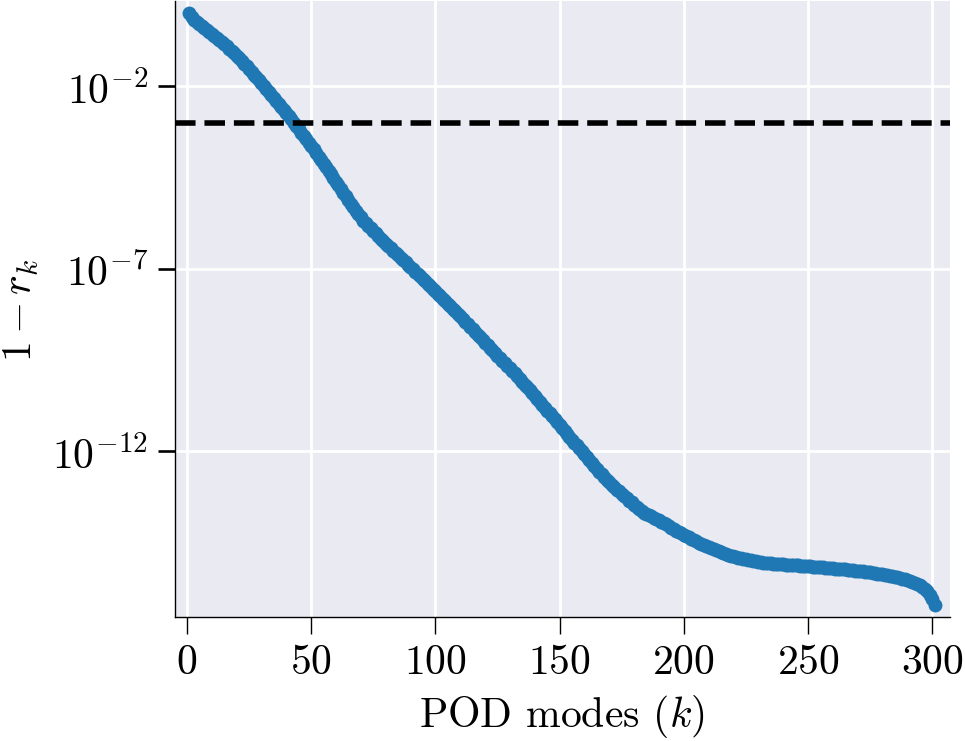

In [24]:
if run_svd:
    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
    plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

    # Perform Singular Value Decomposition (SVD) for POD mode selection
    # SVD decomposes the mean-centered training data to find optimal basis functions
    n_sel, U = svd_mode_selector(NLS_train_ms[0],    # Input: centered training snapshots
                                tolerance=1e-3,    # Convergence criterion for mode selection
                                modes=True)        # Return both number of modes and basis vectors

    # Extract the selected POD basis vectors (spatial modes)
    # V_sel contains the first n_sel most energetic POD modes
    # Shape: [N_dof, n_sel] - each column is a spatial basis function
    V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

    # Set axis labels for the POD energy plot (generated by svd_mode_selector)
    plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
    plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

In [22]:
#### Visualization of SVD modes
if run_svd and visualize:
    mesh = sim_data['mesh'].item()
    for mode_idx in range(min(15, n_sel)):
        mode_vector = V_sel[:, mode_idx]
        save_vtu_point_vertexsample(mode_vector, mesh, sim_data['basis'].item(), Path("mode_shapes/"), f"mode_{mode_idx+1}", point_data_name="POD_Mode")

#### Update basis

In [25]:
if run_svd:

    for i in range(1,len(NLS_train_ms)):
        V_sel = update_basis(V_sel.copy(),NLS_train_ms[i].T, max_modes=int(n_sel/0.85/(i+1)))
        
    np.savez_compressed(rom_dir / f"svd_updated_basis_{i}.npz", V_sel=V_sel)
else:
    V_sel = np.load(rom_dir / f"svd_updated_basis_8.npz")['V_sel']

Projection error after update (relative): 0.0001339755071808978
Projection error after update (relative): 9.744759461391464e-05
Projection error after update (relative): 7.376343126864149e-05
Projection error after update (relative): 7.83632645633627e-05
Projection error after update (relative): 0.00011548055964156598
Projection error after update (relative): 0.00016977677097949914
Projection error after update (relative): 0.00027052296027376544
Projection error after update (relative): 2.1187180315916806e-05
Projection error after update (relative): 0.00017434546160295975


In [26]:
n_sel=V_sel.shape[1]
print(f"Updated number of selected modes: {n_sel}")


Updated number of selected modes: 137


## HyperROM Simulation


In [27]:
from linear_forms import radiation_bdd_hyp

#### Mesh Sampling


In [28]:
prob = Problem3Dprinting()

In [29]:
sim_data['free_dofs'] = prob.domain()['free_dofs']
sim_data['dirichlet_boundary_dofs'] = prob.domain()['bottom_dofs']
# Extract free degrees of freedom (DOFs) 
basis = sim_data['basis'].item()
sim_data['fbasis_non_dir'] = prob.domain()['fbasis_non_dirichlet']

In [30]:
radiation_bdd_rom = LinearFormROM(radiation_bdd_hyp,sim_data['fbasis_non_dir'],V_sel,free_dofs=sim_data['free_dofs']) #np.array(sim_data['fbasis_non_dir'].item().get_dofs().all().tolist()))

In [31]:
training_params = param_list[train_mask]
testing_params = param_list[test_mask]

In [32]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
if _ecsw_snapshots:
    q_mus = collect_residuals_t(
        NLS_train_ms,         # Mean-centered training snapshots
        NLS[train_mask][:,0:1,:],       # Mean temperature field
        V_sel,                # Selected POD basis modes
        reconstruct_solution, # Solution reconstruction function
        radiation_bdd_rom,             # ROM residual operator
        training_params,
        prob.assemble_kwargs_hyperreduction,
        snapshot_downsampling=18,
        hyper_basis=sim_data['fbasis_non_dir']#.item().get_dofs().all().tolist())
    )

    # Display the shape of collected residuals for verification
    # Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
    print(q_mus.shape)
    np.save(rom_dir / "q_mus.npy", q_mus)
else:
    q_mus = np.load(rom_dir / "q_mus.npy")

(23290, 6764)


In [33]:
if _randomized_svd:
    
    from sklearn.utils.extmath import randomized_svd
    print("Performing randomized SVD...")

    # Performs Singular Value Decomposition on q_mus matrix
    # Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)

    r = 900  # target rank
    _, s, Vh = randomized_svd(q_mus, n_components=r, n_iter=4, random_state=0)

    ## Occasionally check with standard SVD

    # print("Performing SVD...")
    # # Performs Singular Value Decomposition on q_mus matrix
    # # Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
    # Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

Performing randomized SVD...


magnitude of d_q: 54.49847220515435


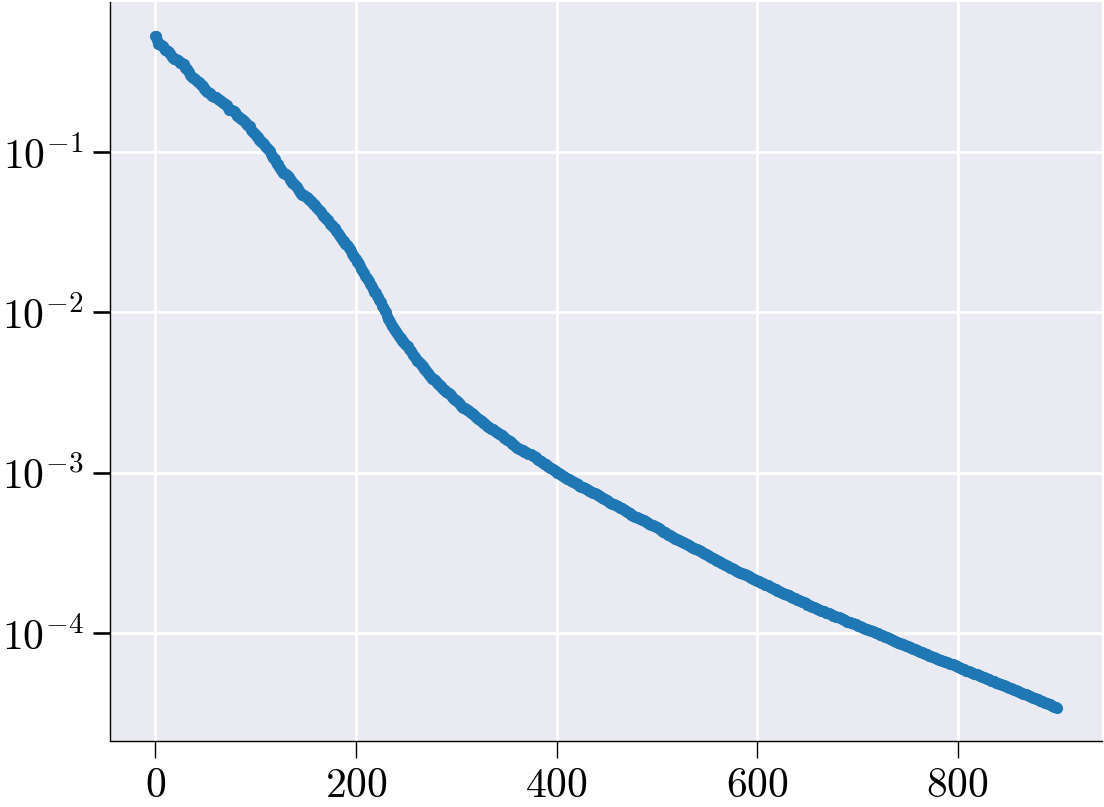

In [34]:
if _randomized_svd:    
    # Plots singular values on a logarithmic y-scale to visualize their decay
    # This helps identify the effective rank/dimensionality of the matrix
    plt.semilogy(s, '.-')

    # Takes the first 20 right singular vectors (rows of Vh)
    # This creates a reduced basis capturing the most significant modes
    V_q_eff = Vh#[:1250]

    # Computes a weighted combination of the basis vectors
    # Each basis vector is weighted equally (multiplied by 1)
    # This essentially sums all 20 basis vectors
    d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

    # Outputs the L2 norm of the resulting vector
    # This gives a sense of the magnitude of the combined basis representation
    print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [36]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting

if _nnls:

    x_nnls_m, err = hyperreduce(
        V_q_eff,
        verbosity=2,
        const_tol=1e-12,
        zero_tol=1e-12,
        plot=False
    )

    # Compute and print the relative NNLS reconstruction error:
    #   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
    rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
    rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
    print("NNLS error:", rel_error)

    np.save(rom_dir/"x_nnls_m.npy", x_nnls_m)

    import gc
    del q_mus,fos_solutions,U
    gc.collect()
else:
    x_nnls_m = np.load(rom_dir/"x_nnls_m.npy")

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 900 6764 0 6.501939700505028e+00 5.449847220515435e+01
1 1 900 6764 1 6.471991662350123e+00 5.433547472584101e+01
2 2 900 6764 2 6.461498143447540e+00 5.421520152941059e+01
3 3 900 6764 3 6.458733213391953e+00 5.415468961462560e+01
4 4 900 6764 4 6.444673601587406e+00 5.410193121063524e+01
5 5 900 6764 5 6.469210581392543e+00 5.404258363963290e+01
6 6 900 6764 6 6.457619328712492e+00 5.396611692608857e+01
7 7 900 6764 7 6.508781358470805e+00 5.391484583189293e+01
8 8 900 6764 8 6.496545904562986e+00 5.386389648200343e+01
9 9 900 6764 9 6.446606672600321e+00 5.367215985358299e+01
10 10 900 6764 10 6.466553977044067e+00 5.359204524783515e+01
11 11 900 6764 11 6.407287063564064e+00 5.353005146461946e+01
12 12 900 6764 12 6.395758766680686e+00 5.348284990508884e+01
13 13 900 6764 13 6.380274825652487e+00 5.334696561456259e+01
14 14 900 6764 14 6.374686897228988e+00 5.328475184468576e+01
15 15 900 6764 15 6.403706622885443e+00

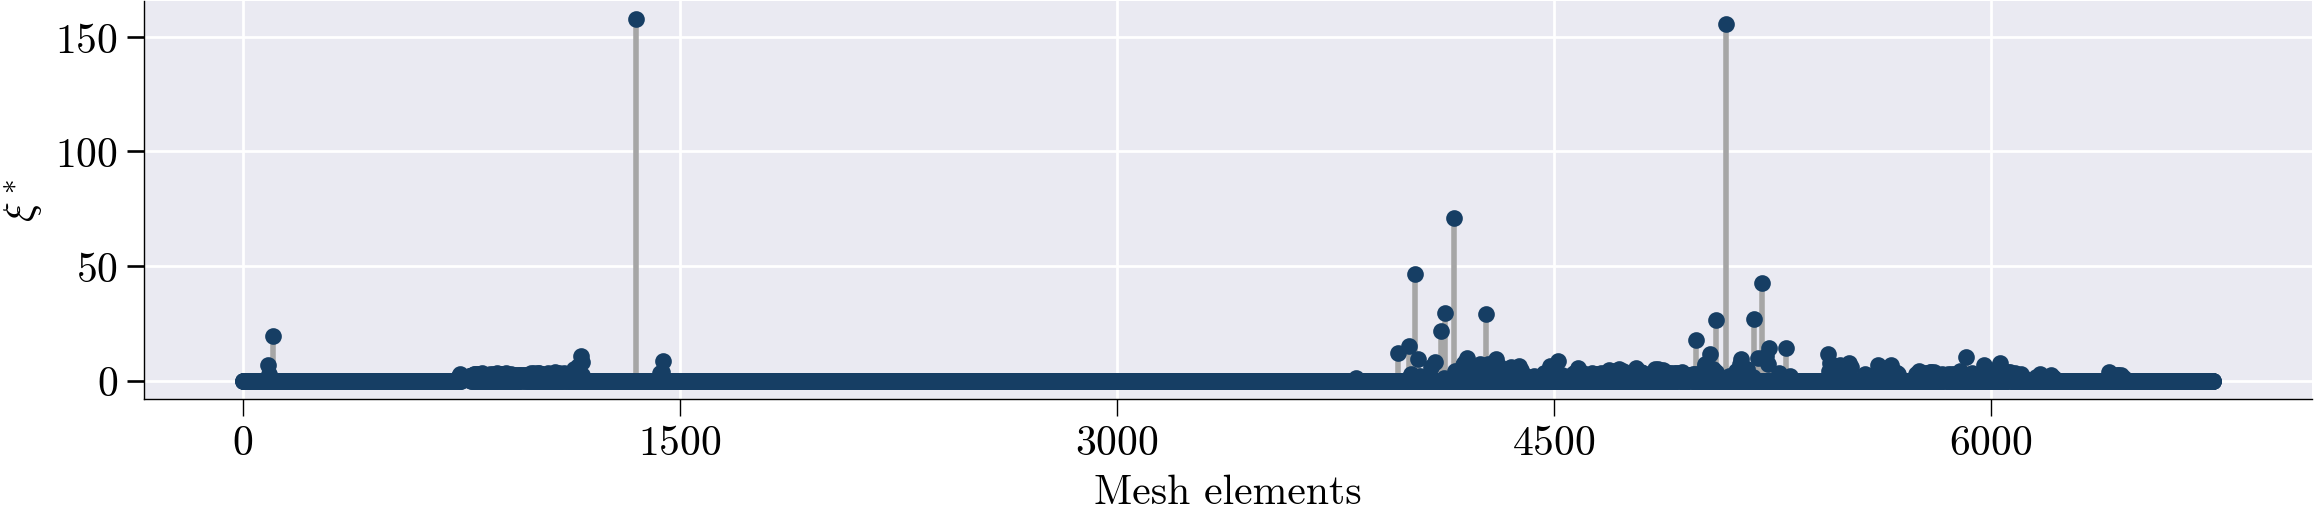

In [37]:
if _nnls:

    fig, ax = plot_ecsw_weights(x_nnls_m)

    ## Mesh coloring based on selected elements

    hyper_basis = sim_data['fbasis_non_dir']
    element_colors = np.zeros(hyper_basis.mesh.nelements)
    element_colors[hyper_basis.tind[np.where(x_nnls_m > 1e-8)[0]]] = 1.0
    hyper_basis.mesh.save('colored_mesh.vtu', cell_data={'element_tags': [element_colors]})

In [40]:
if run_hyperrom:
    # Initialize the reduced-order model (ROM) simulation
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    #   n_sel : number of basis vectors (modes) to retain in the ROM
    rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel, train_mask=train_mask, test_mask=test_mask, train_ref = NLS[train_mask][:,0:1,:], test_ref = NLS[test_mask][:,0:1,:])

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\dynamic\problem_3D_printing_nu_mesh_HO\ROM_data


In [ ]:
if run_hyperrom:

    # Run the hyper-reduced ROM simulation using the NNLS weights
    #   x_nnls_m : array of non-negative least squares coefficients,
    #              used here to weight the reduced basis contributions
    #rom will contain the hyper_rom solution as an attribute
    rom.run_hyper_rom_simulation_ecsw(x_nnls_m,parallel=True,max_workers=8, serial_first=True);
    #rom.run_hyper_rom_simulation(x_nnls_m)

    save_array_list_h5(
    "hyper_rom_solutions.h5",
    rom.hyper_rom_solutions,
    compression="gzip",
    compression_opts=4,
    chunks=True,
    overwrite=True,
    metadata={"tag": "hyper_rom_solutions"}
)

else:
    hyper_rom_solutions = load_array_list_h5("hyper_rom_solutions.h5")
    # or
    # with h5py.File("hyper_rom_solutions.h5", "r") as f:
    # hyper_rom_solutions = [f[k][...] for k in sorted(f.keys())]   # list[np.ndarray]

In [47]:
if run_hyperrom:

    # Convert the list of nonlinear hyper-ROM solutions into a NumPy array
    # NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

    # Retrieve the raw speed-up factors computed by the ROM
    hyper_ROM_speed_up = rom.hyper_speed_up
    np.save("hyper_ROM_speed_up.npy", hyper_ROM_speed_up)
    # Drop the first element (often the full-order baseline) to analyze only relative speed-ups
    # hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

    # Fetch the relative error of the hyper-reduced ROM from the ROM object
    hyper_ROM_relative_error = rom.hyper_rom_error
    np.save("hyper_ROM_relative_errors.npy", hyper_ROM_relative_error)

else:
    hyper_ROM_speed_up = np.load("hyper_ROM_speed_up.npy")
    hyper_ROM_relative_error = np.load("hyper_ROM_relative_errors.npy")

In [ ]:
# current_dir = Path().resolve()
# run_dir = current_dir / "results_hyper_rom_par_"

# save_vtk_time_series_point(
#     NLS_train[0][50:,:],                # shape = (ndofs, n_steps)
#     sim_data['mesh'].item(),
#     run_dir,
#     "sol",
#     interval = 1,
#     point_data_name = "Temperature"
# )

In [48]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
if run_hyperrom:
    matrix = compute_rom_error_metrics_flat(NLS[test_mask][1:,30:,:], np.asarray(rom.hyper_rom_solutions)[1:,30:,:])
else:
    matrix = compute_rom_error_metrics_flat(NLS[test_mask][1:,30:,:], np.asarray(hyper_rom_solutions)[1:,30:,:])

In [49]:
# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

ROM Accuracy Report

Global Errors:
L2 Error:                        1.2707e+05
Relative L2 Error:               1.9818e-02
L∞ Error:                        3.7128e+02
Relative L∞ Error:               7.5808e-02
RMSE:                            8.2177e+00
MAE:                             1.8694e+00

Statistical Fit:
R² Score:                        0.9983
Explained Variance:              0.9984

Error Distribution (absolute):
Median Abs Error:                1.2346e-01
95th Percentile Abs Error:       7.8478e+00

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        1.3962e-02
Max Relative L2 over samples:            3.6609e-02
Min Relative L2 over samples:            1.1923e-03
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


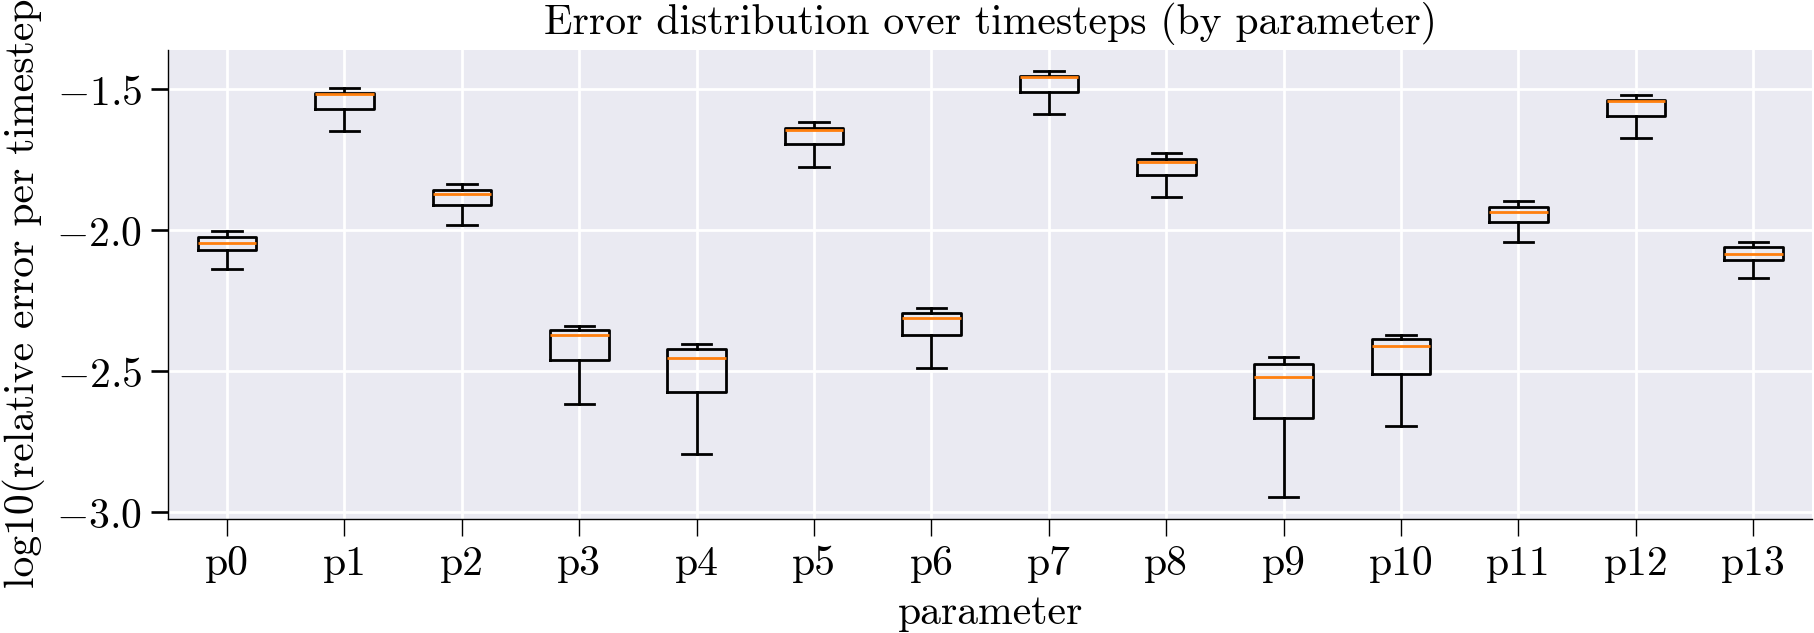

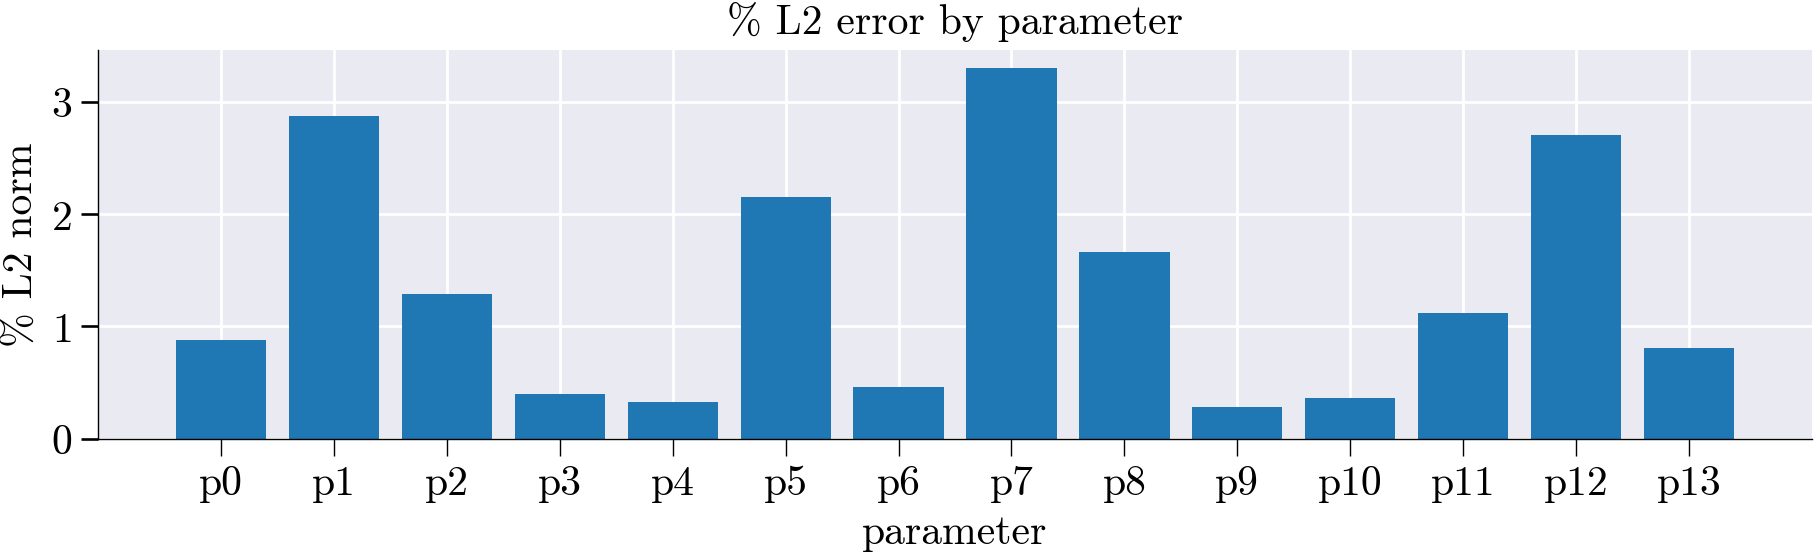

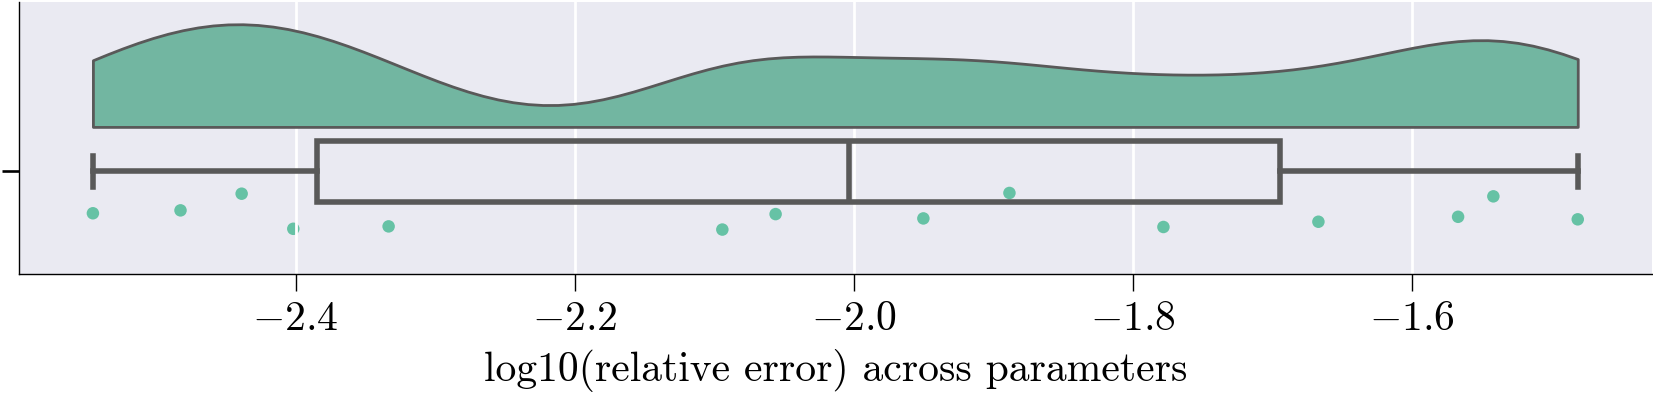

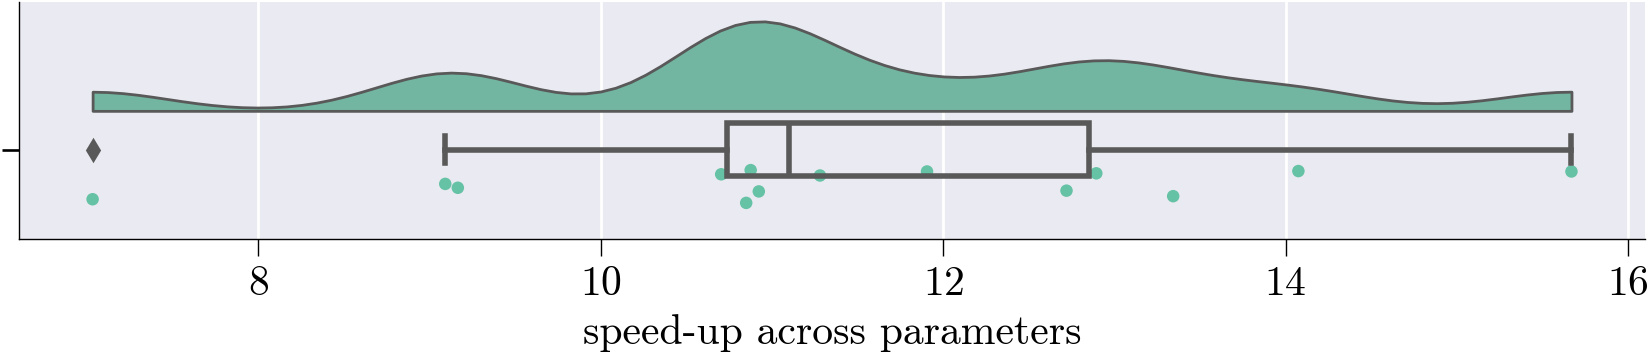

In [50]:
out = plot_rom_param_diagnostics_t(
    NLS[test_mask],
    np.asarray(rom.hyper_rom_solutions),
    l2_per_param=hyper_ROM_relative_error,          # (p,)
    speedup_per_param=hyper_ROM_speed_up, # (p,)
    param_labels=[f"p{i}" for i in range(NLS[test_mask].shape[0])],
    use_raincloud=True,
)


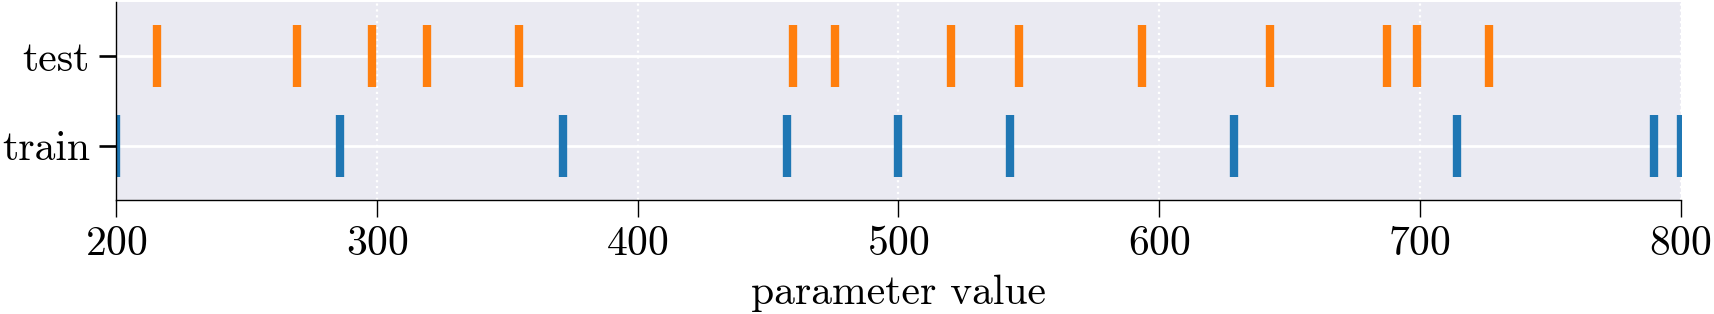

In [51]:
params_train = param_list[train_mask]
params_test = param_list[test_mask]
fig, ax = barcode_plot(params_train, params_test, mode="overlap", bar_size=22, bar_width=3.0)
plt.show()

In [52]:
for j in range(np.asarray(rom.hyper_rom_solutions).shape[0]):
    print(np.max(np.abs(np.asarray(rom.hyper_rom_solutions)[j][50:,:]-NLS[test_mask][j][50:,:])))

70.28873384678491
313.22308042865006
116.44332035655407
19.410283253392663
12.242539428498276
219.91538518298557
26.47804798482457
371.28214644277705
160.28866774075186
7.451594046211767
15.984686826726374
97.0389923673115
291.7165495918498
62.31727762320952


In [ ]:
# current_dir = Path().resolve()
# run_dir = current_dir / "results_rom_error"

# save_vtk_time_series_point(
#     np.abs(NLS_hyper_rom[0][50:,:]-NLS_train[0][50:,:]),                # shape = (ndofs, n_steps)
#     sim_data['mesh'].item(),
#     run_dir,
#     "sol",
#     interval = 1,
#     point_data_name = "Temperature"
# )